# Conférences Python Master TIDE #2

## A) US baby names

Télécharger le dataset national des prénoms US :
- Site : https://www.ssa.gov/oact/babynames/limits.html
- Fichier : https://www.ssa.gov/oact/babynames/names.zip

**Data Preparation**
- Avec une boucle et en utilisant la fonction `concat()` de **pandas** constituer un DataFrame avec l'ensemble des fichiers en ajoutant une colonne avec l'année.
- Ordre et noms des colonnes du DataFrame créé : "year", "name", "gender", "births"

**Data Analysis**
- Quel est le top 16 de la fréquence des prénoms dans le fichier ? Expliquer.
- Calculer la fréquence des genres dans le fichier. Expliquer.
- Ecrire une fonction qui affiche l'évolution des naissances d'un prénom et d'un genre dans le temps.
- Calculer l'évolution du nombre de naissances par année et par genre et afficher un graphique.
- Calculer l'évolution de la diversité des prénoms par année et par genre et afficher un graphique.

**Data Viz**
- Quels sont les 10 prénoms qui ont été les plus donnés.
- Produire un graphique de type `stripplot` avec en x les naissances, en y les 10 prénoms les plus donnés et une couleur différente par nuages de points.

## B) Prénoms français

Télécharger le dataset Fichiers France hors Mayotte de l'INSEE :
- https://www.insee.fr/fr/statistiques/7633685
- https://www.insee.fr/fr/statistiques/fichier/7633685/nat2022_csv.zip

L'idée est de charger les données et ensuite de les conformer au DataFrame des prénoms US. Ainsi, toute manipulation sur le DataFrame des prénoms US pourra être directement réutilisée avec le DataFrame des prénoms français.

**Data Preparation**
- Charger les données dans un DataFrame.
- Utiliser les mêmes noms de colonnes que pour le DataFrame US.
- Eliminer les données inutilisables et les prénoms d'une seule lettre.
- Passer les prénoms en minuscules sauf les initiales qui doivent rester en majuscules. Attention aux prénoms composés.
- Utiliser les mêmes catégories pour le genre.
- Passer les nombres de naissances en entiers.
- Trier le DataFrame à l'identique : années croissantes, genres croissants, naissances décroissantes, prénoms croissants.
- Remettre un index allant de 0 à N-1.

**Data Analysis**
- Ecrire une fonction qui affiche l'évolution des naissances d'un prénom dans le temps.
- Calculer l'évolution du nombre de naissances par année et par genre et afficher un graphique.
- Calculer l'évolution de la diversité des prénoms par année et par genre et afficher un graphique.

## C) Villes du monde et pays

Télécharger le dataset avec les villes du monde de plus de 500 habitants :
- http://www.geonames.org/
- http://download.geonames.org/export/dump/cities500.zip


**Data Preparation**
- Dans un premier temps, charger les données dans un DataFrame avec comme noms de colonnes <code>['geonameid', 'name', 'asciiname', 'alternatenames', 'latitude', 'longitude', 'feature class', 'feature code', 'country code', 'cc2', 'admin1 code', 'admin2 code', 'admin3 code', 'admin4 code', 'population', 'elevation', 'dem', 'timezone', 'modification date']</code>
- On obtient un warning sur des types mixtes : parmi les colonnes qui sont des chaînes de caractères, quelles sont celles qui comportent également des nombres ? (appliquer la méthode de chaîne `isdigit()` sur les colonnes de type `object`).
- Compter le nombre de valeurs manquantes dans chaque colonne : quelle colonnes ne devraient pas avoir de valeurs manquantes ?
- Appliquer `describe()` sur le DataFrame complet, quelle valeur semble être également une valeur manquante ?
- Recharger les données en passant en `str` les colonnes mixtes et en précisant les valeurs manquantes.

**Split-apply-combine strategy**
- Ecrire une fonction qui trouve le nombre de `alternatenames` de chaque ville.
```python
def average_alternate_names(group):
    pass
```
- Calculer la moyenne du nombre de `alternatenames` par `feature code`.

**Jointure**

- Charger le tableau de la page https://www.geonames.org/countries/ avec la fonction **pandas** <code>read_html</code> en prenant garde aux valeurs manquantes par défaut.
- Joindre le DataFrame des villes avec celui des pays.
- Ecrire une fonction qui retourne le nom de la ville la plus peuplée et la tester sur le DataFrame obtenu.
- Appliquer la fonction en groupant par continent.

&copy; Francis Wolinski 2023

In [1]:
import pandas as pd

In [2]:
# A - data prep

dfs = []

for year in range(1880, 2023):
    filename = f'names/yob{year}.txt'
    csv = pd.read_csv(filename, names=['name', 'gender', 'births'])
    csv['year'] = year
    dfs.append(csv)

df = pd.concat(dfs, ignore_index=True)
df = df[['year', 'name', 'gender', 'births']]
df.shape

(2085158, 4)

In [3]:
# A - data analysis - 1

df["name"].value_counts().head(16)

name
Jean       286
Lee        286
John       286
Leslie     286
Joseph     286
William    286
James      286
Tommie     286
Marion     286
Jessie     286
Ollie      286
Johnnie    286
Sidney     286
Jesse      286
Francis    286
Charles    285
Name: count, dtype: int64

In [4]:
# A - data analysis - 2

df["gender"].value_counts()

gender
F    1227795
M     857363
Name: count, dtype: int64

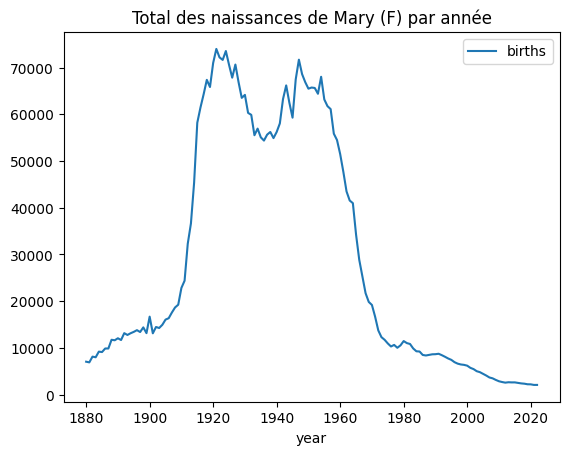

In [5]:
# A - data analysis - 3

def trace_prenom_genre(name, gender):
    var = df.loc[(df["name"] == name) & (df["gender"] == gender)]
    var.plot(title=f"Total des naissances de {name} ({gender}) par année",
             x="year",
             y="births");

trace_prenom_genre("Mary", "F")

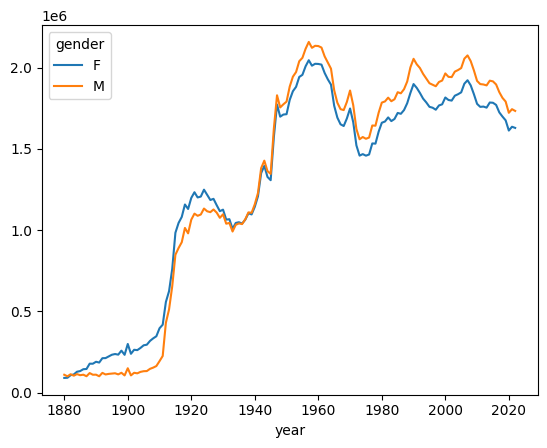

In [6]:
# A - data analysis - 4

(df
 .pivot_table(index="year",
              columns="gender",
              values="births",
              aggfunc='sum')
 .plot
 .line()
);

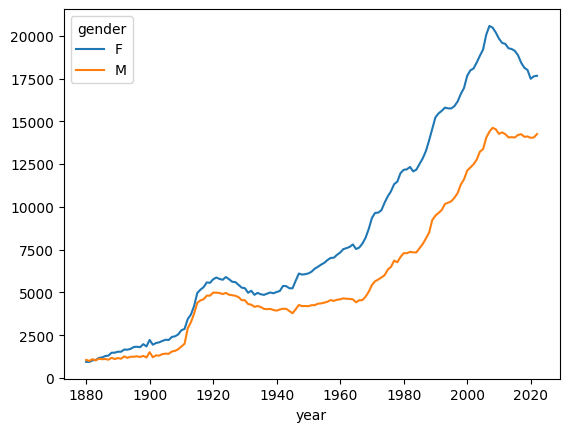

In [7]:
# A - data analysis - 5

(df
 .pivot_table(index="year",
              columns="gender",
              values="name",
              aggfunc='count')
 .plot
 .line()
);

In [8]:
tab = (df
       .pivot_table(index="name", values="births", aggfunc="sum")
       .nlargest(10, "births")
       .index
      )
tab

Index(['James', 'John', 'Robert', 'Michael', 'William', 'Mary', 'David',
       'Joseph', 'Richard', 'Charles'],
      dtype='object', name='name')

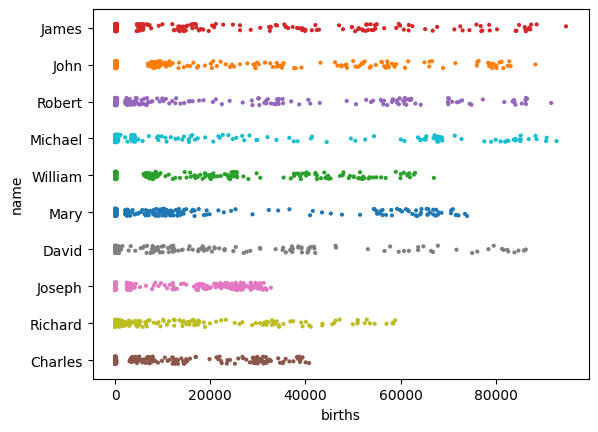

In [10]:
import seaborn as sns

selection = df.loc[df["name"].isin(tab)]
sns.stripplot(data=selection,
              x='births',
              y='name',
              hue='name',
              order=tab,
              palette='tab10',
              size=3);

In [11]:
# B - data prep
df = pd.read_csv('data/nat2022_csv.zip',
                  sep=';',
                  header=0,
                  na_values="",
                  keep_default_na=False,
                  names=['gender', 'name', 'year', 'births'],
                  )

df = df.loc[(df['name'].str.len() > 1) & (df['year'] != 'XXXX') & (df['name'] != '_PRENOMS_RARES')]
df['année'] = df['year'].astype(int)
df['gender'] = df['gender'].map({1:'M', 2:'F'})
df['name'] = df['name'].str.title()
df = df.sort_values(['year', 'gender', 'births', 'name'], ascending=[True, True, False, True])
df = df[['year', 'name', 'gender', 'births']]
df = df.reset_index(drop=True)
df.shape

(663923, 4)

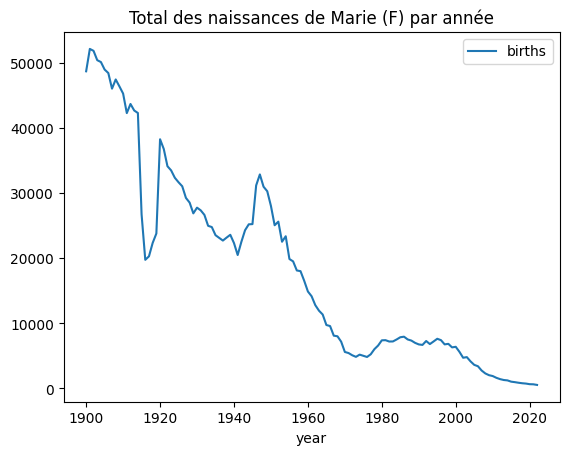

In [12]:
# A - data analysis - 3

def trace_prenom_genre(name, gender):
    var = df.loc[(df["name"] == name) & (df["gender"] == gender)]
    var.plot(title=f"Total des naissances de {name} ({gender}) par année",
             x="year",
             y="births");

trace_prenom_genre("Marie", "F")

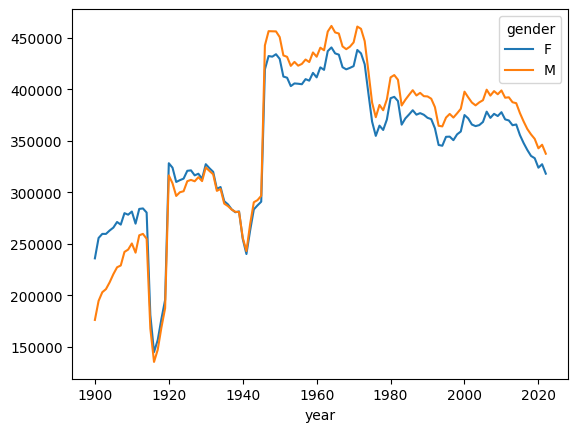

In [13]:
# A - data analysis - 4

(df
 .pivot_table(index="year",
              columns="gender",
              values="births",
              aggfunc='sum')
 .plot
 .line()
);

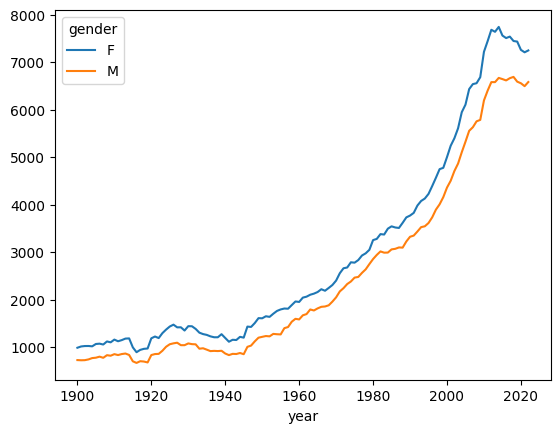

In [14]:
# A - data analysis - 5

(df
 .pivot_table(index="year",
              columns="gender",
              values="name",
              aggfunc='count')
 .plot
 .line()
);

In [15]:
# C - data prep - 1

df = pd.read_csv('data/cities500.zip',
                   sep='\t',
                   header=None,
                   names=['geonameid', 'name', 'asciiname', 'alternatenames', 'latitude', 'longitude', 'feature class', 'feature code', 'country code', 'cc2', 'admin1 code', 'admin2 code', 'admin3 code', 'admin4 code', 'population', 'elevation', 'dem', 'timezone', 'modification date'],)

df.info()

C:\Users\Francis\AppData\Local\Temp\ipykernel_3780\4288289647.py:3: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/cities500.zip',


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 199728 entries, 0 to 199727
Data columns (total 19 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   geonameid          199728 non-null  int64  
 1   name               199727 non-null  object 
 2   asciiname          199710 non-null  object 
 3   alternatenames     164065 non-null  object 
 4   latitude           199728 non-null  float64
 5   longitude          199728 non-null  float64
 6   feature class      199728 non-null  object 
 7   feature code       199728 non-null  object 
 8   country code       199683 non-null  object 
 9   cc2                88 non-null      object 
 10  admin1 code        199701 non-null  object 
 11  admin2 code        179425 non-null  object 
 12  admin3 code        91139 non-null   object 
 13  admin4 code        32645 non-null   object 
 14  population         199728 non-null  int64  
 15  elevation          33540 non-null   float64
 16  de

In [16]:
# C - data prep - 2

df.select_dtypes('object').apply(lambda x: x.str.isdigit()).sum()

name                      0
asciiname                 0
alternatenames            0
feature class             0
feature code              0
country code              0
cc2                       0
admin1 code          163471
admin2 code          151198
admin3 code           85792
admin4 code           29602
timezone                  0
modification date         0
dtype: object

In [17]:
# C - data prep - 3

df.isna().sum()

geonameid                 0
name                      1
asciiname                18
alternatenames        35663
latitude                  0
longitude                 0
feature class             0
feature code              0
country code             45
cc2                  199640
admin1 code              27
admin2 code           20303
admin3 code          108589
admin4 code          167083
population                0
elevation            166188
dem                       0
timezone                  0
modification date         0
dtype: int64

In [18]:
# C - data prep - 4

df.describe()

,geonameid,latitude,longitude,population,elevation,dem
count,1.997280e+05,199728.000000,199728.000000,1.997280e+05,33540.000000,199728.000000
mean,3.566994e+06,32.289465,10.797871,1.837990e+04,294.865444,393.203642
std,2.457474e+06,21.881618,72.303464,1.964920e+05,362.312143,691.602774
min,2.960000e+03,-77.846320,-179.121980,0.000000e+00,-60.000000,-9999.000000
25%,1.910535e+06,20.597485,-36.683888,5.930000e+02,67.000000,52.000000
50%,3.012648e+06,40.658140,10.341235,1.460000e+03,201.000000,182.000000
75%,4.256110e+06,47.527730,42.591675,5.458000e+03,348.250000,457.000000
max,1.254794e+07,78.223340,179.364510,2.231547e+07,3890.000000,5622.000000


In [19]:
# C - data prep - 5

df = pd.read_csv('data/cities500.zip',
                   sep='\t',
                   header=None,
                   names=['geonameid', 'name', 'asciiname', 'alternatenames', 'latitude', 'longitude', 'feature class', 'feature code', 'country code', 'cc2', 'admin1 code', 'admin2 code', 'admin3 code', 'admin4 code', 'population', 'elevation', 'dem', 'timezone', 'modification date'],
                   dtype={'admin1 code': str, 'admin2 code': str, 'admin3 code': str, 'admin4 code': str},
                   keep_default_na=False,
                   na_values=['', -9999])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 199728 entries, 0 to 199727
Data columns (total 19 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   geonameid          199728 non-null  int64  
 1   name               199728 non-null  object 
 2   asciiname          199711 non-null  object 
 3   alternatenames     164065 non-null  object 
 4   latitude           199728 non-null  float64
 5   longitude          199728 non-null  float64
 6   feature class      199728 non-null  object 
 7   feature code       199728 non-null  object 
 8   country code       199728 non-null  object 
 9   cc2                88 non-null      object 
 10  admin1 code        199701 non-null  object 
 11  admin2 code        179798 non-null  object 
 12  admin3 code        91139 non-null   object 
 13  admin4 code        32645 non-null   object 
 14  population         199728 non-null  int64  
 15  elevation          33540 non-null   float64
 16  de

In [20]:
# C - Split-apply-combine strategy - 1

def mean_alternate_names(group):
    return group["alternatenames"].dropna().str.count(",").add(1).mean()

In [21]:
# C - Split-apply-combine strategy - 2

df.groupby('feature code').apply(mean_alternate_names)

feature code
PPL       4.346171
PPLA     18.214669
PPLA2     7.258907
PPLA3     4.585794
PPLA4     5.172788
PPLA5     2.800000
PPLC     50.012448
PPLCH     2.000000
PPLF      2.545455
PPLG     25.285714
PPLH      4.222222
PPLL      2.881279
PPLQ      4.000000
PPLR      2.666667
PPLS      6.600000
PPLW      7.200000
PPLX      2.600000
STLMT     6.195652
dtype: float64

In [22]:
# C - Jointure - 1

var = pd.read_html('https://www.geonames.org/countries/',
                       header=0,
                       keep_default_na=False,
                       encoding='utf-8')
[x.shape for x in var]

[(0, 2), (250, 9)]

In [23]:
# C - Jointure - 2

countries = var[1]
countries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ISO-3166 alpha2   250 non-null    object 
 1   ISO-3166 alpha3   250 non-null    object 
 2   ISO-3166 numeric  250 non-null    int64  
 3   fips              250 non-null    object 
 4   Country           250 non-null    object 
 5   Capital           250 non-null    object 
 6   Area in km²       250 non-null    float64
 7   Population        250 non-null    int64  
 8   Continent         250 non-null    object 
dtypes: float64(1), int64(2), object(6)
memory usage: 17.7+ KB


In [24]:
# C - Jointure - 3

data = pd.merge(df,
              countries,
              left_on="country code",
              right_on="ISO-3166 alpha2",
              how="left")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 199728 entries, 0 to 199727
Data columns (total 28 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   geonameid          199728 non-null  int64  
 1   name               199728 non-null  object 
 2   asciiname          199711 non-null  object 
 3   alternatenames     164065 non-null  object 
 4   latitude           199728 non-null  float64
 5   longitude          199728 non-null  float64
 6   feature class      199728 non-null  object 
 7   feature code       199728 non-null  object 
 8   country code       199728 non-null  object 
 9   cc2                88 non-null      object 
 10  admin1 code        199701 non-null  object 
 11  admin2 code        179798 non-null  object 
 12  admin3 code        91139 non-null   object 
 13  admin4 code        32645 non-null   object 
 14  population         199728 non-null  int64  
 15  elevation          33540 non-null   float64
 16  de

In [25]:
# C - Jointure - 4
def largest_population(group):
    return group.loc[group["population"].idxmax(), "name"]

largest_population(data)

'Shanghai'

In [26]:
# C - Jointure - 5
data.groupby("Continent").apply(largest_population)

Continent
AF              Lagos
AN    McMurdo Station
AS           Shanghai
EU             Moscow
NA        Mexico City
OC             Sydney
SA          São Paulo
dtype: object